In [ ]:
# Our input text
input_text = "The cat sat on the mat"

print("--- Step 0: Input Text ---")
print(f"Original Text: '{input_text}'")
print("-" * 30)

--- Step 0: Input Text ---
Original Text: 'The cat sat on the mat'
------------------------------


In [ ]:
print("\n--- Step 1: Encoding - Text to Numerical IDs ---")

# 1.1. Preprocessing: Convert to lowercase and split into words
processed_words = input_text.lower().split()
print(f"Processed Words: {processed_words}")



--- Step 1: Encoding - Text to Numerical IDs ---
Processed Words: ['the', 'cat', 'sat', 'on', 'the', 'mat']


In [ ]:
# 1.2. Build a vocabulary (word to ID mapping)
word_to_id = {}
next_id = 0
for word in processed_words:
    if word not in word_to_id:
        word_to_id[word] = next_id
        next_id += 1

print(f"Vocabulary (word_to_id): {word_to_id}")

Vocabulary (word_to_id): {'the': 0, 'cat': 1, 'sat': 2, 'on': 3, 'mat': 4}


In [ ]:
# 1.3. Encode the text into a sequence of IDs
encoded_sequence = []
for word in processed_words:
    encoded_sequence.append(word_to_id[word])

print(f"Encoded Sequence (Numerical IDs): {encoded_sequence}")
print("-" * 30)

Encoded Sequence (Numerical IDs): [0, 1, 2, 3, 0, 4]
------------------------------


In [ ]:
import numpy as np

print("\n--- Step 2: The 'Latent Space' - One-Hot Vectors for Each Word ---")

vocab_size = len(word_to_id)
print(f"Dimension of our latent space (vocab size): {vocab_size}")

# Store the one-hot vectors for each word in the original sequence
latent_space_representation = []

for word in processed_words:
    # Create a zero vector of size vocab_size
    one_hot_vector = np.zeros(vocab_size)

    # Get the ID for the current word
    word_id = word_to_id[word]

    # Set the element at the word's ID position to 1
    one_hot_vector[word_id] = 1

    latent_space_representation.append(one_hot_vector)

    print(f"Word: '{word}' -> One-Hot Vector (Latent Space): {one_hot_vector}")

print("\nFull Latent Space Representation (list of one-hot vectors for the sentence):")
for i, vec in enumerate(latent_space_representation):
    print(f"  Word {i+1}: {vec}")

# In a real VAE, this would be a single, continuous vector for the *entire sentence*,
# not a list of discrete vectors for each word. But this shows the word-level latent space.
print("-" * 30)


--- Step 2: The 'Latent Space' - One-Hot Vectors for Each Word ---
Dimension of our latent space (vocab size): 5
Word: 'the' -> One-Hot Vector (Latent Space): [1. 0. 0. 0. 0.]
Word: 'cat' -> One-Hot Vector (Latent Space): [0. 1. 0. 0. 0.]
Word: 'sat' -> One-Hot Vector (Latent Space): [0. 0. 1. 0. 0.]
Word: 'on' -> One-Hot Vector (Latent Space): [0. 0. 0. 1. 0.]
Word: 'the' -> One-Hot Vector (Latent Space): [1. 0. 0. 0. 0.]
Word: 'mat' -> One-Hot Vector (Latent Space): [0. 0. 0. 0. 1.]

Full Latent Space Representation (list of one-hot vectors for the sentence):
  Word 1: [1. 0. 0. 0. 0.]
  Word 2: [0. 1. 0. 0. 0.]
  Word 3: [0. 0. 1. 0. 0.]
  Word 4: [0. 0. 0. 1. 0.]
  Word 5: [1. 0. 0. 0. 0.]
  Word 6: [0. 0. 0. 0. 1.]
------------------------------


In [ ]:
print("\n--- Step 3: Decoding - Latent Space (One-Hot Vectors) back to Text ---")

# 3.1. Create an inverse vocabulary (ID to word mapping)
id_to_word = {id_val: word for word, id_val in word_to_id.items()}
print(f"Inverse Vocabulary (id_to_word): {id_to_word}")

decoded_words = []
for i, one_hot_vector in enumerate(latent_space_representation):
    # Find the index where the value is 1
    # np.argmax returns the index of the maximum value
    word_id = np.argmax(one_hot_vector)

    # Look up the word using its ID
    word = id_to_word[word_id]
    decoded_words.append(word)

    print(f"Vector {i+1}: {one_hot_vector} -> ID: {word_id} -> Word: '{word}'")

# 3.2. Join the words back into a sentence
decoded_text = " ".join(decoded_words)

print(f"\nDecoded Text: '{decoded_text}'")
print("-" * 30)


--- Step 3: Decoding - Latent Space (One-Hot Vectors) back to Text ---
Inverse Vocabulary (id_to_word): {0: 'the', 1: 'cat', 2: 'sat', 3: 'on', 4: 'mat'}
Vector 1: [1. 0. 0. 0. 0.] -> ID: 0 -> Word: 'the'
Vector 2: [0. 1. 0. 0. 0.] -> ID: 1 -> Word: 'cat'
Vector 3: [0. 0. 1. 0. 0.] -> ID: 2 -> Word: 'sat'
Vector 4: [0. 0. 0. 1. 0.] -> ID: 3 -> Word: 'on'
Vector 5: [1. 0. 0. 0. 0.] -> ID: 0 -> Word: 'the'
Vector 6: [0. 0. 0. 0. 1.] -> ID: 4 -> Word: 'mat'

Decoded Text: 'the cat sat on the mat'
------------------------------


In [ ]:
print("\n--- Step 4: Comparison ---")
print(f"Original Text: '{input_text}'")
print(f"Decoded Text:  '{decoded_text}'")

if input_text.lower() == decoded_text.lower():
    print("\nResult: Perfect reconstruction!")
else:
    print("\nResult: Reconstruction mismatch (this shouldn't happen with this simple example).")
print("-" * 30)


--- Step 4: Comparison ---
Original Text: 'The cat sat on the mat'
Decoded Text:  'the cat sat on the mat'

Result: Perfect reconstruction!
------------------------------


--- Step 0: Define Words and Manual Features ---
Words and their assigned 3D feature vectors (latent space coordinates):
  'airplane': [1.0, 0.0, 1.0]
  'jet': [1.0, 0.0, 1.0]
  'wing': [1.0, 0.0, 0.5]
  'cockpit': [0.8, 0.0, 0.8]
  'runway': [1.0, 0.0, 0.7]
  'pilot': [0.5, 0.0, 0.5]
  'helicopter': [0.0, 0.0, 0.7]
  'rotor': [0.0, 0.0, 0.5]
  'blade': [0.0, 0.0, 0.4]
  'chopper': [0.0, 0.0, 0.6]
  'drone': [0.3, 1.0, 0.2]
  'quadcopter': [0.0, 1.0, 0.1]
  'UAV': [0.5, 1.0, 0.3]
  'remote': [0.2, 1.0, 0.1]
  'camera': [0.1, 0.8, 0.0]
  'fly': [0.5, 0.5, 0.5]
  'sky': [0.5, 0.5, 0.5]
  'air': [0.5, 0.5, 0.5]
--------------------------------------------------

--- Step 1: Prepare Data for 3D Plotting ---
X-coordinates (Fixed-Wing/Rotary): [1.  1.  1.  0.8 1.  0.5 0.  0.  0.  0.  0.3 0.  0.5 0.2 0.1 0.5 0.5 0.5]
Y-coordinates (Unmanned/Manned): [0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  1.  1.  1.  0.8 0.5 0.5 0.5]
Z-coordinates (Size/Complexity): [1.  1.  0.5 0.8 0.7 0.5 0.7 0.5 0.4 0

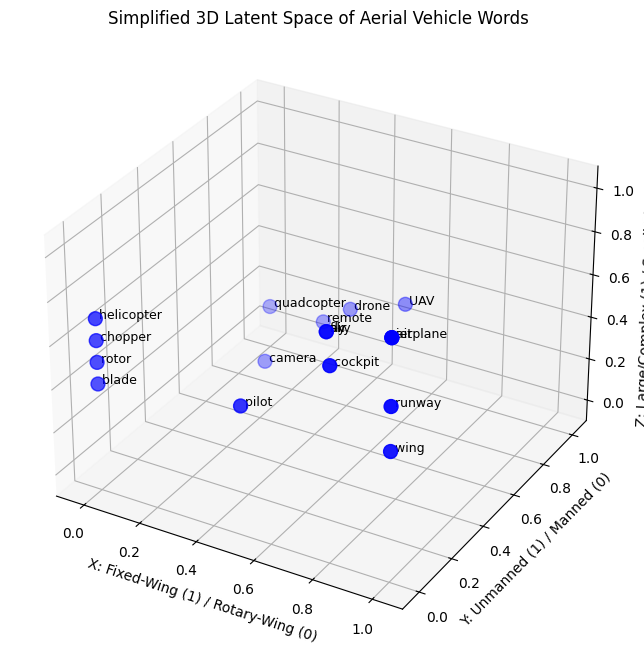

--------------------------------------------------

--- Interpretation ---
In this manually constructed 3D 'latent space':
- Words related to 'airplane' (e.g., 'jet', 'runway') tend to cluster towards X=1 (Fixed-Wing), Y=0 (Manned), Z=1 (Large).
- Words related to 'helicopter' (e.g., 'rotor', 'chopper') tend to cluster towards X=0 (Rotary-Wing), Y=0 (Manned), Z=0.5-0.7 (Medium-Large).
- Words related to 'drone' (e.g., 'quadcopter', 'UAV', 'remote') tend to cluster towards Y=1 (Unmanned), and lower Z (Small/Simple). Their X-coordinate can vary as drones can be fixed-wing or rotary-wing.
- General words like 'fly', 'sky', 'air' are placed near the center (0.5, 0.5, 0.5) as they don't strongly lean towards any specific feature.

This demonstrates how a latent space can represent words as points in a multi-dimensional space, where proximity implies similarity based on the defined features.


In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

print("--- Step 0: Define Words and Manual Features ---")

# Define words and their manually assigned feature values (0 to 1)
# Features: [Fixed-Wing (1) / Rotary-Wing (0), Unmanned (1) / Manned (0), Small (0) / Large (1)]
# Note: These are subjective and simplified for demonstration.

word_features = {
    # Airplanes
    "airplane":      [1.0, 0.5, 1.0], # Fixed-wing, Manned, Large
    "jet":           [1.0, 0.0, 1.0], # Fixed-wing, Manned, Large
    "wing":          [1.0, 0.0, 0.5], # Fixed-wing, Manned (part), Medium size relevance
    "cockpit":       [0.8, 0.0, 0.8], # Mostly fixed-wing, Manned, Large
    "runway":        [1.0, 0.0, 0.7], # Fixed-wing, Manned, Large
    "pilot":         [0.5, 0.0, 0.5], # Can be for any, but often manned

    # Helicopters
    "helicopter":    [0.0, 0.0, 0.7], # Rotary-wing, Manned, Medium-Large
    "rotor":         [0.0, 0.0, 0.5], # Rotary-wing, Manned (part), Medium size relevance
    "blade":         [0.0, 0.0, 0.4], # Rotary-wing, Manned (part), Medium size relevance
    "chopper":       [0.0, 0.0, 0.6], # Rotary-wing, Manned, Medium

    # Drones
    "drone":         [0.3, 1.0, 0.2], # Can be fixed/rotary, Unmanned, Small
    "quadcopter":    [0.0, 1.0, 0.1], # Rotary-wing, Unmanned, Small
    "UAV":           [0.5, 1.0, 0.3], # Can be fixed/rotary, Unmanned, Small-Medium
    "remote":        [0.2, 1.0, 0.1], # Unmanned control, Small
    "camera":        [0.1, 0.8, 0.0], # Often on drones, Unmanned, Small

    # General/Overlap
    "fly":           [0.5, 0.5, 0.5], # General, can be manned/unmanned, any size
    "sky":           [0.5, 0.5, 0.5], # General
    "air":           [0.5, 0.5, 0.5], # General
}

print("Words and their assigned 3D feature vectors (latent space coordinates):")
for word, vec in word_features.items():
    print(f"  '{word}': {vec}")

print("-" * 50)

print("\n--- Step 1: Prepare Data for 3D Plotting ---")

# Extract coordinates and labels
words = list(word_features.keys())
vectors = np.array(list(word_features.values()))

x_coords = vectors[:, 0]
y_coords = vectors[:, 1]
z_coords = vectors[:, 2]

print(f"X-coordinates (Fixed-Wing/Rotary): {x_coords}")
print(f"Y-coordinates (Unmanned/Manned): {y_coords}")
print(f"Z-coordinates (Size/Complexity): {z_coords}")

print("-" * 50)

print("\n--- Step 2: Visualize the Latent Space in 3D ---")

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the points
ax.scatter(x_coords, y_coords, z_coords, c='blue', marker='o', s=100)

# Label the points with the words
for i, word in enumerate(words):
    ax.text(x_coords[i], y_coords[i], z_coords[i], f' {word}', size=9, zorder=1, color='k')

# Set labels for the axes
ax.set_xlabel('X: Fixed-Wing (1) / Rotary-Wing (0)')
ax.set_ylabel('Y: Unmanned (1) / Manned (0)')
ax.set_zlabel('Z: Large/Complex (1) / Small/Simple (0)')

ax.set_title('Simplified 3D Latent Space of Aerial Vehicle Words')

# Set axis limits for better visualization
ax.set_xlim([-0.1, 1.1])
ax.set_ylim([-0.1, 1.1])
ax.set_zlim([-0.1, 1.1])

plt.show()

print("-" * 50)
print("\n--- Interpretation ---")
print("In this manually constructed 3D 'latent space':")
print("- Words related to 'airplane' (e.g., 'jet', 'runway') tend to cluster towards X=1 (Fixed-Wing), Y=0 (Manned), Z=1 (Large).")
print("- Words related to 'helicopter' (e.g., 'rotor', 'chopper') tend to cluster towards X=0 (Rotary-Wing), Y=0 (Manned), Z=0.5-0.7 (Medium-Large).")
print("- Words related to 'drone' (e.g., 'quadcopter', 'UAV', 'remote') tend to cluster towards Y=1 (Unmanned), and lower Z (Small/Simple). Their X-coordinate can vary as drones can be fixed-wing or rotary-wing.")
print("- General words like 'fly', 'sky', 'air' are placed near the center (0.5, 0.5, 0.5) as they don't strongly lean towards any specific feature.")
print("\nThis demonstrates how a latent space can represent words as points in a multi-dimensional space, where proximity implies similarity based on the defined features.")

--- Step 0: Define VAR Concepts and Manual Features ---
Concepts and their assigned 3D feature vectors (latent space coordinates):
  'VAR model': [0.9, 0.7, 0.0]
  'Vector Autoregression': [0.9, 0.7, 0.0]
  'multivariate': [0.8, 0.5, 0.0]
  'time series': [0.5, 0.5, 0.5]
  'endogenous': [1.0, 0.5, 0.0]
  'lag order': [0.5, 1.0, 0.0]
  'Granger causality': [0.9, 0.8, 0.0]
  'impulse response': [0.9, 0.8, 0.0]
  'forecast': [0.7, 0.7, 0.5]
  'AR model': [0.1, 0.3, 0.0]
  'ARIMA': [0.2, 0.6, 0.0]
  'exogenous': [0.0, 0.0, 1.0]
  'VARX model': [0.9, 0.7, 1.0]
  'cointegration': [0.8, 0.9, 0.0]
  'stationarity': [0.5, 0.5, 0.0]
  'variables': [0.5, 0.5, 0.5]
--------------------------------------------------

--- Step 1: Prepare Data for 3D Plotting ---
X-coordinates (Endogeneity): [0.9 0.9 0.8 0.5 1.  0.5 0.9 0.9 0.7 0.1 0.2 0.  0.9 0.8 0.5 0.5]
Y-coordinates (Lag Complexity): [0.7 0.7 0.5 0.5 0.5 1.  0.8 0.8 0.7 0.3 0.6 0.  0.7 0.9 0.5 0.5]
Z-coordinates (Exogeneity): [0.  0.  0.  0.5 0. 

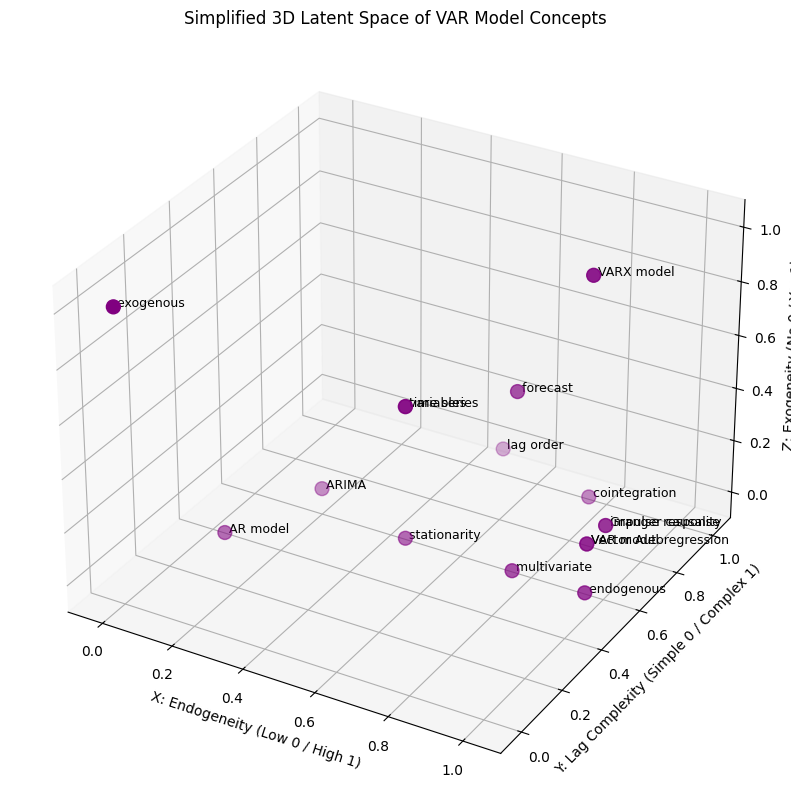

--------------------------------------------------

--- Interpretation ---
In this manually constructed 3D 'latent space' for VAR concepts:
- Core 'VAR model' concepts (e.g., 'Vector Autoregression', 'multivariate', 'endogenous') cluster towards high X (Endogeneity).
- Concepts related to the past (e.g., 'lag order', 'cointegration') tend to have higher Y (Lag Complexity).
- The 'VARX model' and 'exogenous' stand out with high Z (Exogeneity), differentiating them from pure VAR models.
- Simpler univariate models like 'AR model' are located at low X (Endogeneity) and low Y (Lag Complexity).
- General concepts like 'time series' or 'variables' are closer to the center, as they don't strongly emphasize any single feature.

This visualization helps to conceptually map statistical terms based on their defining characteristics, much like a learned latent space would group similar concepts.


In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

print("--- Step 0: Define VAR Concepts and Manual Features ---")

# Define VAR-related concepts and their manually assigned feature values (0 to 1)
# Features: [Endogeneity (0=Low, 1=High), Lag Complexity (0=Simple, 1=Complex), Exogeneity (0=No, 1=Yes)]

concept_features = {
    # Core VAR concepts
    "VAR model":         [0.9, 0.7, 0.0], # High endogeneity, moderate lag complexity (general), no exogenous
    "Vector Autoregression": [0.9, 0.7, 0.0], # Same as above
    "multivariate":      [0.8, 0.5, 0.0], # High endogeneity, general lag, no exogenous
    "time series":       [0.5, 0.5, 0.5], # General concept, moderate on all
    "endogenous":        [1.0, 0.5, 0.0], # Focus on high endogeneity, general lag, no exogenous
    "lag order":         [0.5, 1.0, 0.0], # Focus on high lag complexity, general endogeneity, no exogenous
    "Granger causality": [0.9, 0.8, 0.0], # High endogeneity, moderate lag, no exogenous (tests for interdependence)
    "impulse response":  [0.9, 0.8, 0.0], # High endogeneity, moderate lag, no exogenous (analyzes interdependence)
    "forecast":          [0.7, 0.7, 0.5], # Moderate endogeneity, moderate lag, can be with/without exogenous

    # Related/Contrasting concepts
    "AR model":          [0.1, 0.3, 0.0], # Low endogeneity (univariate), simple lag, no exogenous
    "ARIMA":             [0.2, 0.6, 0.0], # Low endogeneity (univariate), moderate lag, no exogenous
    "exogenous":         [0.0, 0.0, 1.0], # Focus on high exogeneity, low endogeneity/lag (as a concept)
    "VARX model":        [0.9, 0.7, 1.0], # High endogeneity, moderate lag, *with* exogenous
    "cointegration":     [0.8, 0.9, 0.0], # High endogeneity, complex lag (long-run relationships), no exogenous
    "stationarity":      [0.5, 0.5, 0.0], # General requirement, moderate on others
    "variables":         [0.5, 0.5, 0.5], # General concept
}

print("Concepts and their assigned 3D feature vectors (latent space coordinates):")
for concept, vec in concept_features.items():
    print(f"  '{concept}': {vec}")

print("-" * 50)

print("\n--- Step 1: Prepare Data for 3D Plotting ---")

# Extract coordinates and labels
concepts = list(concept_features.keys())
vectors = np.array(list(concept_features.values()))

x_coords = vectors[:, 0]
y_coords = vectors[:, 1]
z_coords = vectors[:, 2]

print(f"X-coordinates (Endogeneity): {x_coords}")
print(f"Y-coordinates (Lag Complexity): {y_coords}")
print(f"Z-coordinates (Exogeneity): {z_coords}")

print("-" * 50)

print("\n--- Step 2: Visualize the Latent Space in 3D ---")

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot the points
ax.scatter(x_coords, y_coords, z_coords, c='purple', marker='o', s=100)

# Label the points with the concepts
for i, concept in enumerate(concepts):
    ax.text(x_coords[i], y_coords[i], z_coords[i], f' {concept}', size=9, zorder=1, color='k')

# Set labels for the axes
ax.set_xlabel('X: Endogeneity (Low 0 / High 1)')
ax.set_ylabel('Y: Lag Complexity (Simple 0 / Complex 1)')
ax.set_zlabel('Z: Exogeneity (No 0 / Yes 1)')

ax.set_title('Simplified 3D Latent Space of VAR Model Concepts')

# Set axis limits for better visualization
ax.set_xlim([-0.1, 1.1])
ax.set_ylim([-0.1, 1.1])
ax.set_zlim([-0.1, 1.1])

plt.show()

print("-" * 50)
print("\n--- Interpretation ---")
print("In this manually constructed 3D 'latent space' for VAR concepts:")
print("- Core 'VAR model' concepts (e.g., 'Vector Autoregression', 'multivariate', 'endogenous') cluster towards high X (Endogeneity).")
print("- Concepts related to the past (e.g., 'lag order', 'cointegration') tend to have higher Y (Lag Complexity).")
print("- The 'VARX model' and 'exogenous' stand out with high Z (Exogeneity), differentiating them from pure VAR models.")
print("- Simpler univariate models like 'AR model' are located at low X (Endogeneity) and low Y (Lag Complexity).")
print("- General concepts like 'time series' or 'variables' are closer to the center, as they don't strongly emphasize any single feature.")
print("\nThis visualization helps to conceptually map statistical terms based on their defining characteristics, much like a learned latent space would group similar concepts.")

In [ ]:
print("\n--- Step 1: Encoding - Text to Latent Space Vectors ---")

# 1.1. Preprocessing: Convert to lowercase and split into words
processed_words = input_text.lower().split()
print(f"Processed Words: {processed_words}")

# 1.2. Encode each word into its 3D latent space vector
encoded_latent_space = []
unknown_words = []

for word in processed_words:
    if word in word_features:
        encoded_latent_space.append(word_features[word])
    else:
        # Handle words not in our defined vocabulary
        # In a real VAE, it would learn to represent these.
        # Here, we'll assign a neutral vector and note it.
        encoded_latent_space.append([0.5, 0.5, 0.5]) # Neutral vector for unknown words
        unknown_words.append(word)

print("\nEncoded Latent Space (List of 3D Vectors for the sentence):")
for i, vec in enumerate(encoded_latent_space):
    print(f"  '{processed_words[i]}': {vec}")

if unknown_words:
    print(f"\nNote: The following words were not in our predefined vocabulary and were assigned a neutral vector: {unknown_words}")

print("-" * 50)


--- Step 1: Encoding - Text to Latent Space Vectors ---
Processed Words: ['the', 'cat', 'sat', 'on', 'the', 'mat']

Encoded Latent Space (List of 3D Vectors for the sentence):
  'the': [0.5, 0.5, 0.5]
  'cat': [0.5, 0.5, 0.5]
  'sat': [0.5, 0.5, 0.5]
  'on': [0.5, 0.5, 0.5]
  'the': [0.5, 0.5, 0.5]
  'mat': [0.5, 0.5, 0.5]

Note: The following words were not in our predefined vocabulary and were assigned a neutral vector: ['the', 'cat', 'sat', 'on', 'the', 'mat']
--------------------------------------------------



--- Step 2: Visualize the Latent Space of the Encoded Sentence ---

Plot saved to 'latent_space_sentence_visualization.png'


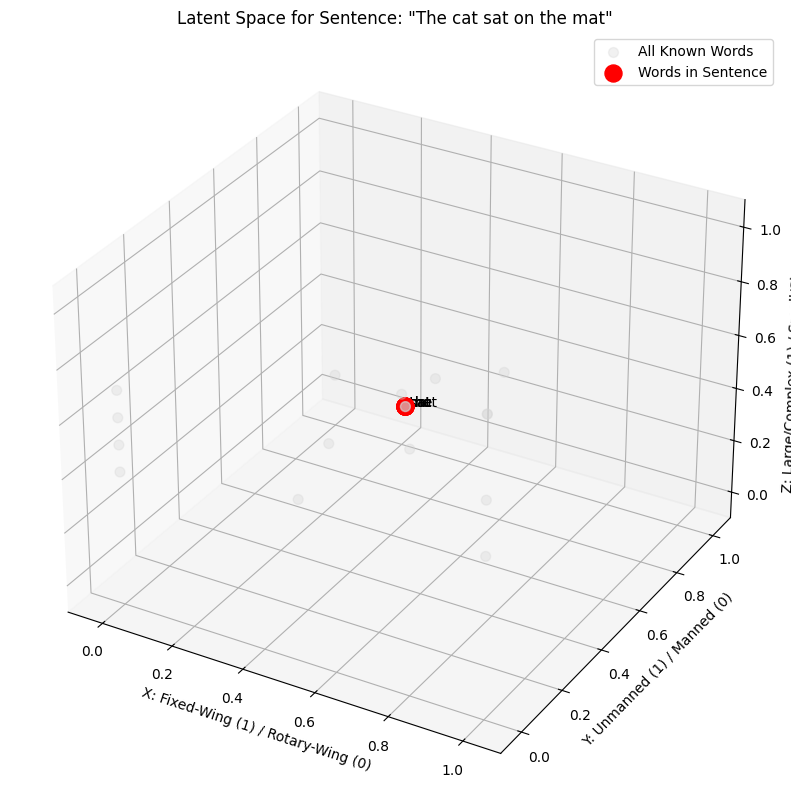

--------------------------------------------------


In [ ]:
print("\n--- Step 2: Visualize the Latent Space of the Encoded Sentence ---")

# Extract coordinates for the encoded sentence
sentence_vectors = np.array(encoded_latent_space)
sentence_words = processed_words

x_sent = sentence_vectors[:, 0]
y_sent = sentence_vectors[:, 1]
z_sent = sentence_vectors[:, 2]

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot all known words as background (lighter color)
all_words = list(word_features.keys())
all_vectors = np.array(list(word_features.values()))
ax.scatter(all_vectors[:, 0], all_vectors[:, 1], all_vectors[:, 2], c='lightgray', marker='o', s=50, alpha=0.3, label='All Known Words')

# Plot the words from our sentence (darker color, larger size)
ax.scatter(x_sent, y_sent, z_sent, c='red', marker='o', s=150, label='Words in Sentence')

# Label the points from the sentence
for i, word in enumerate(sentence_words):
    ax.text(x_sent[i], y_sent[i], z_sent[i], f' {word}', size=10, zorder=1, color='k')

# Set labels for the axes
ax.set_xlabel('X: Fixed-Wing (1) / Rotary-Wing (0)')
ax.set_ylabel('Y: Unmanned (1) / Manned (0)')
ax.set_zlabel('Z: Large/Complex (1) / Small/Simple (0)')

ax.set_title(f'Latent Space for Sentence: "{input_text}"')
ax.set_xlim([-0.1, 1.1])
ax.set_ylim([-0.1, 1.1])
ax.set_zlim([-0.1, 1.1])
ax.legend()

# --- ADDED LINES TO SAVE THE PLOT ---
plot_filename = "latent_space_sentence_visualization.png"
plt.savefig(plot_filename)
print(f"\nPlot saved to '{plot_filename}'")
# --- END OF ADDED LINES ---

plt.show() # This will still attempt to display the plot if in an interactive environment

print("-" * 50)

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from collections import defaultdict

print("--- Step 0: Define Words, Features, and Training Sentences ---")

# Define words and their manually assigned feature values (0 to 1)
# Features: [Fixed-Wing (1) / Rotary-Wing (0), Unmanned (1) / Manned (0), Large/Complex (1) / Small/Simple (0)]
word_features = {
    "airplane":      [1.0, 0.0, 1.0],
    "jet":           [1.0, 0.0, 1.0],
    "wing":          [1.0, 0.0, 0.5],
    "cockpit":       [0.8, 0.0, 0.8],
    "runway":        [1.0, 0.0, 0.7],
    "pilot":         [0.5, 0.0, 0.5],
    "helicopter":    [0.0, 0.0, 0.7],
    "rotor":         [0.0, 0.0, 0.5],
    "blade":         [0.0, 0.0, 0.4],
    "chopper":       [0.0, 0.0, 0.6],
    "drone":         [0.3, 1.0, 0.2],
    "quadcopter":    [0.0, 1.0, 0.1],
    "UAV":           [0.5, 1.0, 0.3],
    "remote":        [0.2, 1.0, 0.0],
    "camera":        [0.1, 0.8, 0.0],
    "fly":           [0.5, 0.5, 0.5],
    "sky":           [0.5, 0.5, 0.5],
    "air":           [0.5, 0.5, 0.5],
    "the":           [0.5, 0.5, 0.5],
    "a":             [0.5, 0.5, 0.5],
    "is":            [0.5, 0.5, 0.5],
    "and":           [0.5, 0.5, 0.5],
    "over":          [0.5, 0.5, 0.5],
    "new":           [0.5, 0.5, 0.5],
    "small":         [0.0, 0.0, 0.0],
    "large":         [1.0, 1.0, 1.0],
    "flies":         [0.5, 0.5, 0.5], # Added for input sentence
    "takes":         [0.5, 0.5, 0.5], # Added for training sentences
    "off":           [0.5, 0.5, 0.5], # Added for training sentences
    "with":          [0.5, 0.5, 0.5], # Added for training sentences
    "its":           [0.5, 0.5, 0.5], # Added for training sentences
    "big":           [1.0, 1.0, 1.0], # Similar to large
    "from":          [0.5, 0.5, 0.5], # Neutral
    "base":          [0.5, 0.5, 0.5], # Neutral
    "to":            [0.5, 0.5, 0.5], # Neutral
    "monitor":       [0.2, 0.9, 0.1], # Drone-like activity
    "area":          [0.5, 0.5, 0.5], # Neutral
}

# --- Our "Training Data" (sentences and their expected latent representations) ---
# In a real VAE, these would be learned. Here, we'll pre-calculate them.
training_sentences = [
    "The large airplane takes off from the runway",
    "A small drone flies with its camera",
    "The helicopter flies over the area to monitor",
    "A new jet is on the runway",
    "The quadcopter is a small drone",
    "Pilot flies the large helicopter",
    "The pilot is in the cockpit of the airplane",
    "A small UAV monitors the area",
    "The rotor blade of the chopper is big",
]

# --- Function to encode a single sentence into a 3D vector ---
def encode_sentence_to_3d_vector(sentence, word_features_map):
    processed_words = sentence.lower().split()
    word_vectors = []
    for word in processed_words:
        if word in word_features_map:
            word_vectors.append(word_features_map[word])
        else:
            # Assign a neutral vector for unknown words
            word_vectors.append([0.5, 0.5, 0.5])

    if not word_vectors: # Handle empty sentences
        return np.array([0.5, 0.5, 0.5])

    # Average the word vectors to get a single sentence vector
    return np.mean(word_vectors, axis=0)

# Pre-calculate latent vectors for all training sentences
training_latent_vectors = {}
for sentence in training_sentences:
    training_latent_vectors[sentence] = encode_sentence_to_3d_vector(sentence, word_features)

print("\nTraining Sentences and their Latent Vectors:")
for sent, vec in training_latent_vectors.items():
    print(f"  '{sent}' -> {vec}")

print("-" * 50)

# --- Our input text to encode and decode ---
input_text = "A small drone flies over the large airplane"

print(f"\nInput Text for Encoding: '{input_text}'")
print("-" * 50)

--- Step 0: Define Words, Features, and Training Sentences ---

Training Sentences and their Latent Vectors:
  'The large airplane takes off from the runway' -> [0.6875 0.4375 0.65  ]
  'A small drone flies with its camera' -> [0.34285714 0.54285714 0.31428571]
  'The helicopter flies over the area to monitor' -> [0.4    0.4875 0.475 ]
  'A new jet is on the runway' -> [0.64285714 0.35714286 0.6       ]
  'The quadcopter is a small drone' -> [0.3        0.58333333 0.3       ]
  'Pilot flies the large helicopter' -> [0.5  0.4  0.64]
  'The pilot is in the cockpit of the airplane' -> [0.58888889 0.33333333 0.58888889]
  'A small UAV monitors the area' -> [0.41666667 0.41666667 0.41666667]
  'The rotor blade of the chopper is big' -> [0.375  0.375  0.5625]
--------------------------------------------------

Input Text for Encoding: 'A small drone flies over the large airplane'
--------------------------------------------------


In [ ]:
print("\n--- Step 1: Encoding - Input Text to a Single 3D Latent Vector ---")

# Use our helper function to encode the input sentence
input_latent_vector = encode_sentence_to_3d_vector(input_text, word_features)

print(f"Input Sentence: '{input_text}'")
print(f"Encoded Latent Space Vector for Input Sentence: {input_latent_vector}")

print("-" * 50)


--- Step 1: Encoding - Input Text to a Single 3D Latent Vector ---
Input Sentence: 'A small drone flies over the large airplane'
Encoded Latent Space Vector for Input Sentence: [0.5375 0.5    0.525 ]
--------------------------------------------------



--- Step 2: Visualize the Latent Space ---

Plot saved to 'latent_space_sentence_level.png'


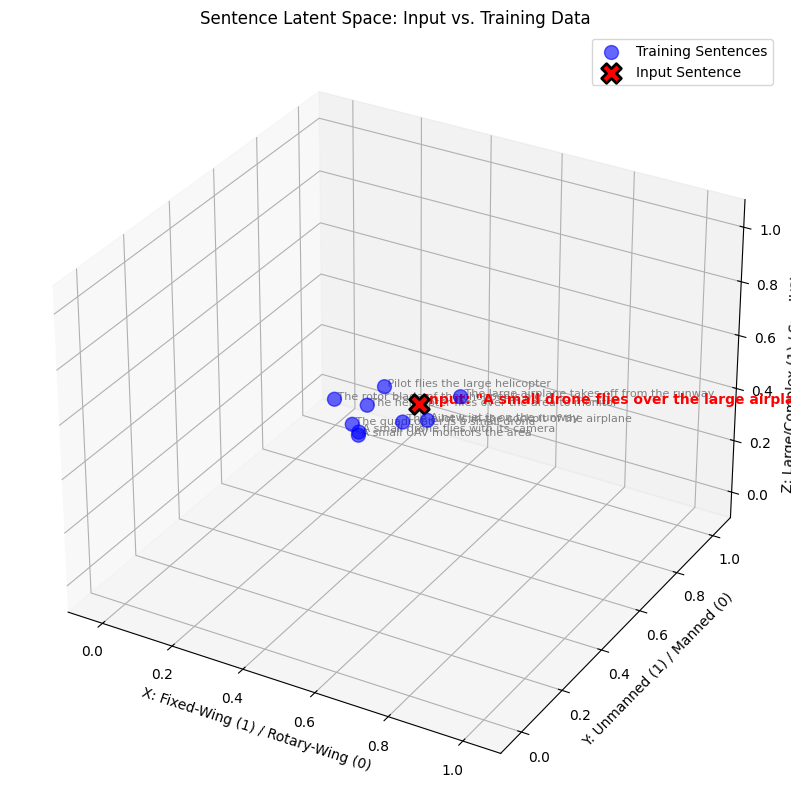

--------------------------------------------------


In [ ]:
print("\n--- Step 2: Visualize the Latent Space ---")

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot training sentences
train_x, train_y, train_z = [], [], []
for sent, vec in training_latent_vectors.items():
    train_x.append(vec[0])
    train_y.append(vec[1])
    train_z.append(vec[2])
    ax.text(vec[0], vec[1], vec[2], f' {sent}', size=8, zorder=1, color='gray') # Label training sentences

ax.scatter(train_x, train_y, train_z, c='blue', marker='o', s=100, alpha=0.6, label='Training Sentences')

# Plot the input sentence's latent vector
ax.scatter(input_latent_vector[0], input_latent_vector[1], input_latent_vector[2],
           c='red', marker='X', s=200, label='Input Sentence', edgecolor='black', linewidth=2)
ax.text(input_latent_vector[0], input_latent_vector[1], input_latent_vector[2],
        f' Input: "{input_text}"', size=10, zorder=1, color='red', weight='bold')

# Set labels for the axes
ax.set_xlabel('X: Fixed-Wing (1) / Rotary-Wing (0)')
ax.set_ylabel('Y: Unmanned (1) / Manned (0)')
ax.set_zlabel('Z: Large/Complex (1) / Small/Simple (0)')

ax.set_title('Sentence Latent Space: Input vs. Training Data')
ax.set_xlim([-0.1, 1.1])
ax.set_ylim([-0.1, 1.1])
ax.set_zlim([-0.1, 1.1])
ax.legend()

plot_filename_sentence = "latent_space_sentence_level.png"
plt.savefig(plot_filename_sentence)
print(f"\nPlot saved to '{plot_filename_sentence}'")

plt.show()

print("-" * 50)

In [ ]:
print("\n--- Step 3: Decoding - Single 3D Latent Vector back to Text ---")

min_distance = float('inf')
decoded_sentence = "UNKNOWN SENTENCE"
closest_training_vector = None

print(f"Input Latent Vector: {input_latent_vector}")
print("\nComparing to Training Sentence Latent Vectors:")

for sent, vec in training_latent_vectors.items():
    distance = np.linalg.norm(input_latent_vector - vec)
    print(f"  '{sent}' (Vector: {vec}) -> Distance: {distance:.4f}")

    if distance < min_distance:
        min_distance = distance
        decoded_sentence = sent
        closest_training_vector = vec

print(f"\nClosest Training Sentence Found: '{decoded_sentence}'")
print(f"Its Latent Vector: {closest_training_vector}")
print(f"Distance to Input Latent Vector: {min_distance:.4f}")

print("-" * 50)


--- Step 3: Decoding - Single 3D Latent Vector back to Text ---
Input Latent Vector: [0.5375 0.5    0.525 ]

Comparing to Training Sentence Latent Vectors:
  'The large airplane takes off from the runway' (Vector: [0.6875 0.4375 0.65  ]) -> Distance: 0.2050
  'A small drone flies with its camera' (Vector: [0.34285714 0.54285714 0.31428571]) -> Distance: 0.2900
  'The helicopter flies over the area to monitor' (Vector: [0.4    0.4875 0.475 ]) -> Distance: 0.1468
  'A new jet is on the runway' (Vector: [0.64285714 0.35714286 0.6       ]) -> Distance: 0.1927
  'The quadcopter is a small drone' (Vector: [0.3        0.58333333 0.3       ]) -> Distance: 0.3376
  'Pilot flies the large helicopter' (Vector: [0.5  0.4  0.64]) -> Distance: 0.1569
  'The pilot is in the cockpit of the airplane' (Vector: [0.58888889 0.33333333 0.58888889]) -> Distance: 0.1857
  'A small UAV monitors the area' (Vector: [0.41666667 0.41666667 0.41666667]) -> Distance: 0.1824
  'The rotor blade of the chopper is big

In [ ]:
print("\n--- Step 4: Comparison ---")
print(f"Original Input Text: '{input_text}'")
print(f"Decoded Output Text (Closest Training Sentence): '{decoded_sentence}'")

# Note: This is not a direct reconstruction but a retrieval of the most similar known sentence.
# A true VAE decoder would *generate* a new sentence.
if input_text.lower() == decoded_sentence.lower():
    print("\nResult: Perfect reconstruction (input sentence was identical to a training sentence).")
else:
    print("\nResult: Decoded output is the most semantically similar sentence from our training data based on the latent space.")
print("-" * 50)


--- Step 4: Comparison ---
Original Input Text: 'A small drone flies over the large airplane'
Decoded Output Text (Closest Training Sentence): 'The helicopter flies over the area to monitor'

Result: Decoded output is the most semantically similar sentence from our training data based on the latent space.
--------------------------------------------------


In [ ]:
# Import necessary libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Print the shapes of the loaded data
print("Shape of x_train:", x_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of x_test:", x_test.shape)
print("Shape of y_test:", y_test.shape)

# Print the data type of the images
print("Data type of x_train:", x_train.dtype)

# Print the minimum and maximum pixel values
print("Minimum pixel value in x_train:", np.min(x_train))
print("Maximum pixel value in x_train:", np.max(x_train))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Shape of x_train: (60000, 28, 28)
Shape of y_train: (60000,)
Shape of x_test: (10000, 28, 28)
Shape of y_test: (10000,)
Data type of x_train: uint8
Minimum pixel value in x_train: 0
Maximum pixel value in x_train: 255


Displaying a few MNIST training images:


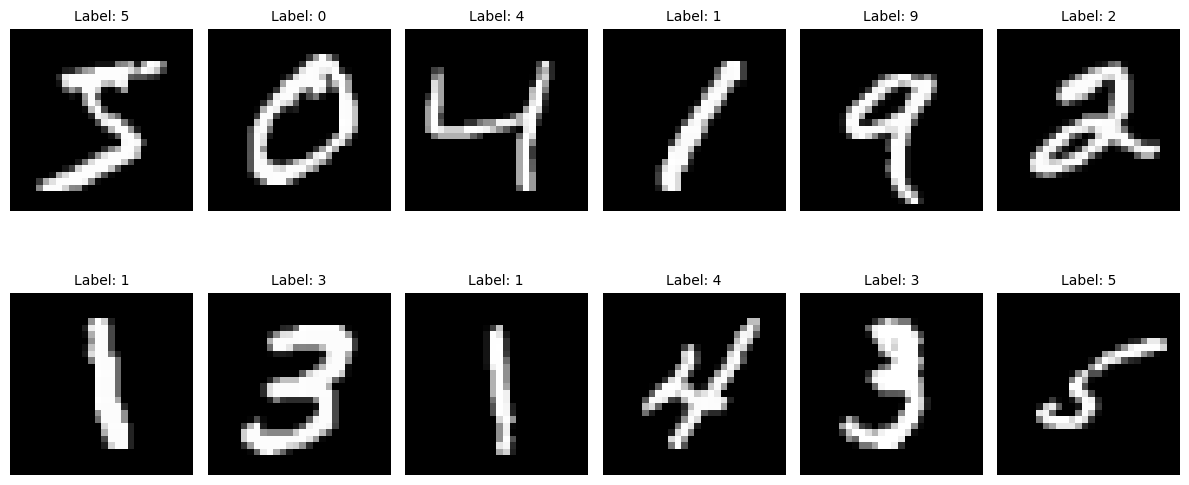


These are the handwritten digits that our model will learn to understand and generate.
Each image is 28x28 pixels, and the 'Label' tells us what digit it represents.


In [ ]:
# Import necessary libraries (already done, but good to reiterate)
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load the MNIST dataset (already done)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# --- Revised code for visualization ---

print("Displaying a few MNIST training images:")

# Create a figure to hold our plots
plt.figure(figsize=(12, 6)) # Adjusted figure size for better display

# Loop through the first 12 images in the training set
for i in range(12):
    # Create a subplot for each image
    plt.subplot(2, 6, i + 1) # 2 rows, 6 columns, current plot index

    # Display the image
    plt.imshow(x_train[i], cmap='gray') # cmap='gray' makes it grayscale

    # Add the corresponding label as the title
    plt.title(f"Label: {y_train[i]}", fontsize=10) # Smaller font for title

    # Remove axis ticks for cleaner display
    plt.axis('off')

# Adjust layout to prevent titles from overlapping
plt.tight_layout()

# Show the plot
plt.show()

print("\nThese are the handwritten digits that our model will learn to understand and generate.")
print("Each image is 28x28 pixels, and the 'Label' tells us what digit it represents.")

Displaying Image and its Full Pixel Matrix for Label: 5



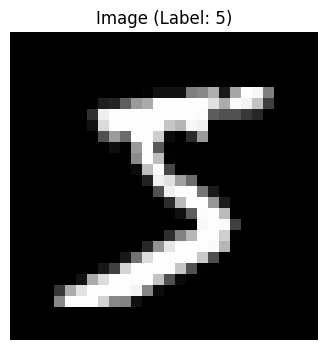


Full Pixel Matrix for the selected image:
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0
  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0
  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0
  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 1

In [ ]:
# Assuming x_train and y_train are already loaded from previous steps

# Choose an image to display (e.g., the first one)
image_index = 0 # You can change this to any number between 0 and 59999
sample_image = x_train[image_index]
sample_label = y_train[image_index]

print(f"Displaying Image and its Full Pixel Matrix for Label: {sample_label}\n")

# Plot the image
plt.figure(figsize=(4, 4)) # Smaller figure size
plt.imshow(sample_image, cmap='gray')
plt.title(f"Image (Label: {sample_label})")
plt.axis('off')
plt.show()

print("\nFull Pixel Matrix for the selected image:")
# Print the full matrix for the students to see the complete numerical representation
# We'll use a custom print function to make it more readable
def print_matrix_nicely(matrix):
    for row in matrix:
        print(" ".join(f"{val:3d}" for val in row)) # Format each number to 3 digits, right-aligned

print_matrix_nicely(sample_image)

In [ ]:
# Assuming x_train and x_test are already loaded from previous steps

print("Original shape of x_train:", x_train.shape)
print("Original data type of x_train:", x_train.dtype)
print("Original min/max pixel values:", np.min(x_train), "/", np.max(x_train))

# 1. Normalize pixel values to [0, 1]
# We convert to float32 first because division by 255 will result in floats
x_train_processed = x_train.astype('float32') / 255.0
x_test_processed = x_test.astype('float32') / 255.0

print("\nAfter Normalization:")
print("New data type of x_train_processed:", x_train_processed.dtype)
print("New min/max pixel values:", np.min(x_train_processed), "/", np.max(x_train_processed))

# 2. Reshape images from 28x28 to 784 (flatten)
# The VAE's input layer will typically expect a 1D vector for each image
image_size = x_train.shape[1] * x_train.shape[2] # 28 * 28 = 784
x_train_processed = x_train_processed.reshape(-1, image_size)
x_test_processed = x_test_processed.reshape(-1, image_size)

print("\nAfter Reshaping (Flattening):")
print("New shape of x_train_processed:", x_train_processed.shape)
print("New shape of x_test_processed:", x_test_processed.shape)

# Store the processed data for later use
# We'll use these processed versions for training the VAE
# You might want to keep the original x_train/x_test for visualization later
# if you want to compare original vs. reconstructed images easily.
# For now, let's just make sure we have the processed versions.

Original shape of x_train: (60000, 28, 28)
Original data type of x_train: uint8
Original min/max pixel values: 0 / 255

After Normalization:
New data type of x_train_processed: float32
New min/max pixel values: 0.0 / 1.0

After Reshaping (Flattening):
New shape of x_train_processed: (60000, 784)
New shape of x_test_processed: (10000, 784)


Why Normalize? (Scaling to 0-1):

"Right now, our pixel values go from 0 (black) to 255 (white). Most neural networks, including our VAE, prefer input values to be in a smaller, more consistent range, often between 0 and 1."

"Think of it like this: if you have numbers ranging from 0 to 255, a small change in a pixel value (say, from 10 to 11) might not seem like much, but it's a bigger 'jump' than if the range was 0 to 1."

"By dividing every pixel value by 255, we scale everything down. So, 0 stays 0, 255 becomes 1, and 127.5 becomes 0.5. This helps the VAE learn more efficiently and prevents some values from dominating others just because they are numerically larger."

"We also change the data type to float32 because we're dealing with decimal numbers now."
Why Reshape? (Flattening):


"Currently, each image is a 28x28 grid. While convolutional neural networks (CNNs) can work directly with these 2D grids, the basic VAE architecture we'll start with often expects a single, long list of numbers for each image."

"Imagine taking each row of pixels from the 28x28 grid and stacking them end-to-end. You'd get one long list of 28 * 28 = 784 numbers."

"So, we're transforming each 28x28 image into a 1D vector of 784 pixel values. This is called 'flattening' the image."
"Our VAE's first layer will take these 784 numbers as input."

In [ ]:
import numpy as np

# --- Configuration (same as before) ---
original_dim = 784 # 28 * 28
latent_dim = 2

# --- Define the architecture (number of neurons in each layer) ---
hidden_layer_1_units = 256
hidden_layer_2_units = 128 # Let's keep it simple for manual, maybe just one hidden layer for now

# --- Initialize Weights and Biases Manually ---
# In a real scenario, these would be learned during training.
# For demonstration, we'll initialize them randomly.
# Using a fixed random seed for reproducibility.
np.random.seed(42)

# Weights and biases for the first hidden layer
# Input (784) -> Hidden 1 (256)
W1 = np.random.randn(original_dim, hidden_layer_1_units) * 0.01 # Small random weights
b1 = np.zeros(hidden_layer_1_units)

# Weights and biases for the second hidden layer (if used)
# Hidden 1 (256) -> Hidden 2 (128)
W2 = np.random.randn(hidden_layer_1_units, hidden_layer_2_units) * 0.01
b2 = np.zeros(hidden_layer_2_units)

# Weights and biases for z_mean output
# Hidden 2 (128) -> z_mean (2)
W_mean = np.random.randn(hidden_layer_2_units, latent_dim) * 0.01
b_mean = np.zeros(latent_dim)

# Weights and biases for z_log_var output
# Hidden 2 (128) -> z_log_var (2)
W_log_var = np.random.randn(hidden_layer_2_units, latent_dim) * 0.01
b_log_var = np.zeros(latent_dim)

# --- Activation Functions ---
def relu(x):
    return np.maximum(0, x)

def sigmoid(x): # Not used in encoder, but good to have for general NN
    return 1 / (1 + np.exp(-x))

# --- The Manual Encoder Function ---
def manual_encoder(input_image_vector, weights_and_biases):
    # Unpack weights and biases
    W1, b1, W2, b2, W_mean, b_mean, W_log_var, b_log_var = weights_and_biases

    # Ensure input is a 1D vector
    if input_image_vector.ndim == 1:
        input_image_vector = input_image_vector.reshape(1, -1) # Make it a row vector

    # Hidden Layer 1
    # Calculation: input * W1 + b1
    # input_image_vector (1, 784) @ W1 (784, 256) -> h1_pre_activation (1, 256)
    h1_pre_activation = np.dot(input_image_vector, W1) + b1
    h1_activated = relu(h1_pre_activation)

    # Hidden Layer 2
    # h1_activated (1, 256) @ W2 (256, 128) -> h2_pre_activation (1, 128)
    h2_pre_activation = np.dot(h1_activated, W2) + b2
    h2_activated = relu(h2_pre_activation)

    # Output for z_mean
    # h2_activated (1, 128) @ W_mean (128, 2) -> z_mean (1, 2)
    z_mean = np.dot(h2_activated, W_mean) + b_mean

    # Output for z_log_var
    # h2_activated (1, 128) @ W_log_var (128, 2) -> z_log_var (1, 2)
    z_log_var = np.dot(h2_activated, W_log_var) + b_log_var

    # Sampling (reparameterization trick)
    # We need to ensure epsilon has the same shape as z_mean/z_log_var
    epsilon = np.random.randn(*z_mean.shape) # Sample from standard normal distribution
    z = z_mean + np.exp(0.5 * z_log_var) * epsilon

    return z_mean, z_log_var, z

# --- Example Usage ---
# Assuming x_train_processed is available from previous steps
# Let's take the first processed image
sample_input = x_train_processed[0]

# Pack all weights and biases into a tuple
encoder_params = (W1, b1, W2, b2, W_mean, b_mean, W_log_var, b_log_var)

# Run the manual encoder
z_mean_val, z_log_var_val, z_val = manual_encoder(sample_input, encoder_params)

print(f"Input image shape: {sample_input.shape}")
print(f"Output z_mean shape: {z_mean_val.shape}")
print(f"Output z_log_var shape: {z_log_var_val.shape}")
print(f"Output z (sampled latent vector) shape: {z_val.shape}")

print("\nExample output for a single image:")
print("z_mean:", z_mean_val)
print("z_log_var:", z_log_var_val)
print("z (sampled latent vector):", z_val)

Input image shape: (784,)
Output z_mean shape: (1, 2)
Output z_log_var shape: (1, 2)
Output z (sampled latent vector) shape: (1, 2)

Example output for a single image:
z_mean: [[0.00038536 0.00117584]]
z_log_var: [[ 0.00138039 -0.00014297]]
z (sampled latent vector): [[-0.79732581 -0.21362007]]


In [ ]:
import keras

x_train shape: (60000, 784)
x_test shape: (10000, 784)


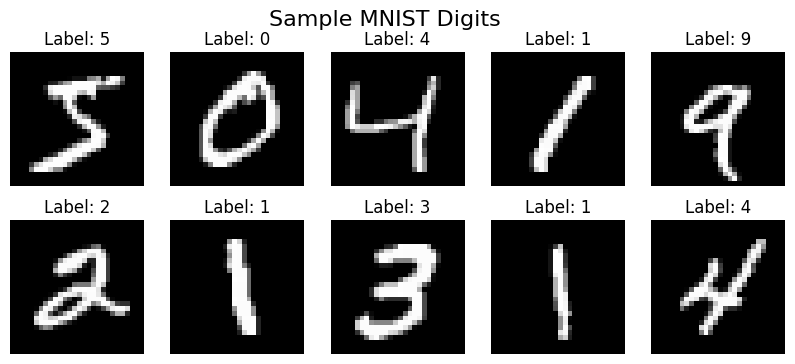

In [ ]:
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize and reshape the data
# Images are 28x28 grayscale. We flatten them to 784-dimensional vectors.
# Pixel values are scaled from [0, 255] to [0, 1].
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten images for dense layers
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

# Print shapes to confirm
print(f"x_train shape: {x_train.shape}") # (60000, 784)
print(f"x_test shape: {x_test.shape}")   # (10000, 784)

# Display a few sample images
plt.figure(figsize=(10, 4))
for i in range(10):
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.suptitle("Sample MNIST Digits", fontsize=16)
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms
from torchvision.utils import save_image, make_grid
import matplotlib.pyplot as plt
import numpy as np
import os

# --- MODIFICATION START ---
# Set device to CPU
device = torch.device("cpu")
# --- MODIFICATION END ---

print(f"Using device: {device}")

# Create a directory to save generated images
if not os.path.exists('vae_samples'):
    os.makedirs('vae_samples')

Using device: cpu


In [ ]:
# Define a transformation to normalize and convert images to tensors
transform = transforms.Compose([
    transforms.ToTensor(),
    # Normalize to [-1, 1] if you prefer, but [0, 1] is fine for MNIST
    # transforms.Normalize((0.5,), (0.5,))
])

# Load the MNIST training dataset
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)

# Create a DataLoader to batch and shuffle the data
batch_size = 128
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of batches: {len(train_loader)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 341kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.72MB/s]

Number of training samples: 60000
Number of batches: 469


Shape of a batch of images: torch.Size([128, 1, 28, 28])


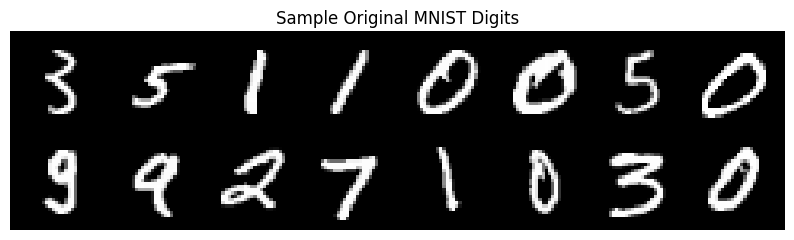

In [ ]:
# Get one batch of training data
data_iter = iter(train_loader)
images, labels = next(data_iter)

print(f"Shape of a batch of images: {images.shape}") # Expected: [batch_size, 1, 28, 28]

# Display a grid of original images
def show_images(images, title="Original Images"):
    # --- MODIFICATION START ---
    # Ensure images are on CPU before converting to numpy
    grid = make_grid(images.cpu(), nrow=8, normalize=True)
    # --- MODIFICATION END ---
    plt.figure(figsize=(10, 10))
    plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
    plt.title(title)
    plt.axis('off')
    plt.show()

show_images(images[:16], title="Sample Original MNIST Digits")

In [ ]:
#...............................

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses

# For reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from tensorflow.keras.datasets import mnist

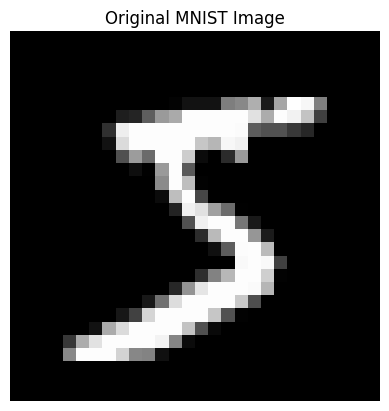

In [ ]:
# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Pick one sample image
img_original = x_train[0]

# Show image
plt.imshow(img_original, cmap='gray')
plt.title("Original MNIST Image")
plt.axis("off")
plt.show()


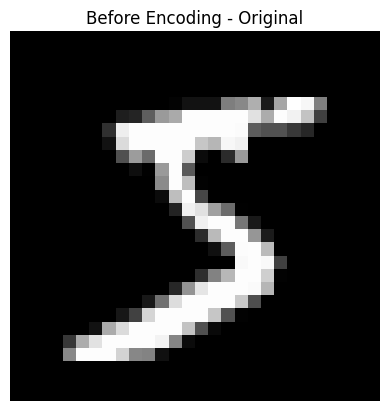

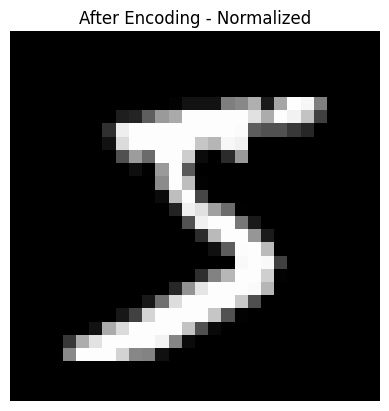

In [ ]:
# BEFORE (Original)
plt.imshow(img_original, cmap='gray')
plt.title("Before Encoding - Original")
plt.axis("off")
plt.show()

# Encoding Step
img_norm = img_original / 255.0

# AFTER (Normalized)
plt.imshow(img_norm, cmap='gray')
plt.title("After Encoding - Normalized")
plt.axis("off")
plt.show()

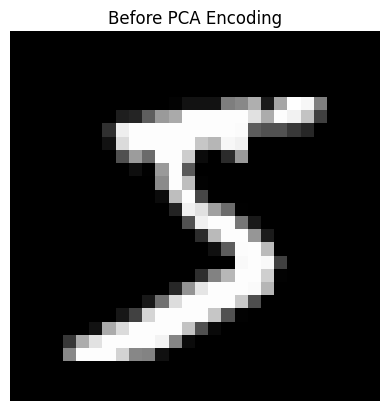

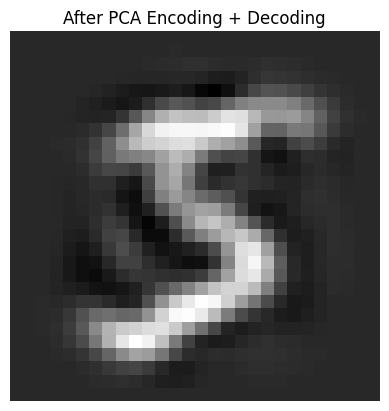

In [ ]:
# Prepare dataset for PCA
x_train_norm = x_train / 255.0
x_train_flat = x_train_norm.reshape(len(x_train_norm), 784)

# Train PCA Encoder
pca = PCA(n_components=50)
pca.fit(x_train_flat)

# BEFORE (Input Image)
plt.imshow(img_norm, cmap='gray')
plt.title("Before PCA Encoding")
plt.axis("off")
plt.show()

# Encoding
img_pca_encoded = pca.transform(img_flat.reshape(1, -1))

# Decode (Reconstruct)
img_pca_decoded = pca.inverse_transform(img_pca_encoded)
img_pca_image = img_pca_decoded.reshape(28, 28)

# AFTER (Encoded + Decoded Image)
plt.imshow(img_pca_image, cmap='gray')
plt.title("After PCA Encoding + Decoding")
plt.axis("off")
plt.show()


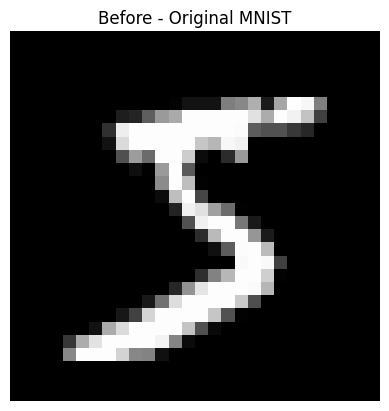

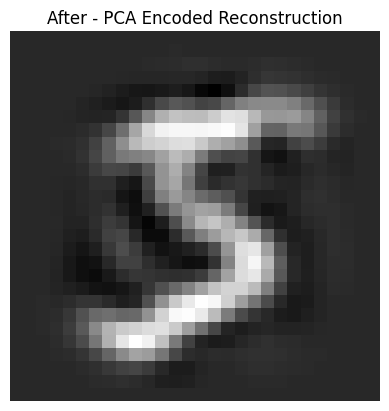

In [ ]:
# BEFORE (Original)
plt.imshow(img_original, cmap='gray')
plt.title("Before - Original MNIST")
plt.axis("off")
plt.show()

# AFTER (Encoded + Decoded Final Output)
plt.imshow(img_pca_image, cmap='gray')
plt.title("After - PCA Encoded Reconstruction")
plt.axis("off")
plt.show()

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

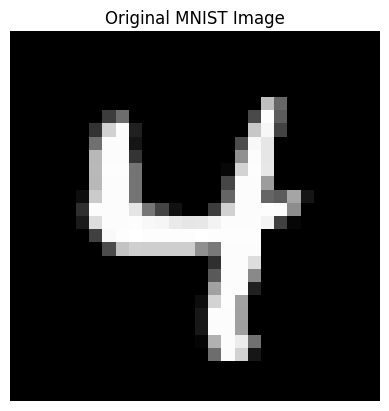

In [ ]:
# Load MNIST
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True
)

# Take one sample
data_iter = iter(train_loader)
image_tensor, label = next(data_iter)

# Convert to numpy for display
img_original = image_tensor[0][0].numpy()

plt.imshow(img_original, cmap='gray')
plt.title("Original MNIST Image")
plt.axis("off")
plt.show()


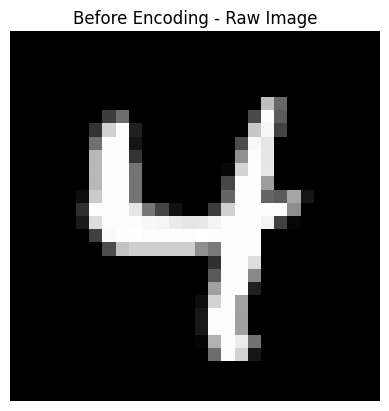

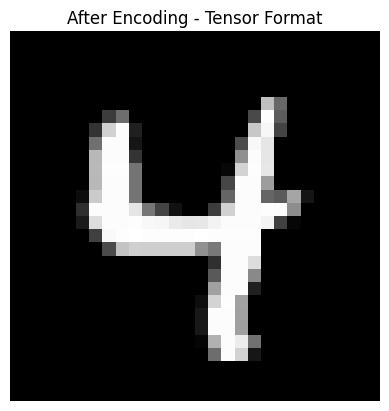

In [ ]:
# BEFORE
plt.imshow(img_original, cmap='gray')
plt.title("Before Encoding - Raw Image")
plt.axis("off")
plt.show()

# Encoding (Already Tensor, just clone to show step)
img_tensor = image_tensor.clone()

# AFTER
img_after_tensor = img_tensor[0][0].numpy()

plt.imshow(img_after_tensor, cmap='gray')
plt.title("After Encoding - Tensor Format")
plt.axis("off")
plt.show()


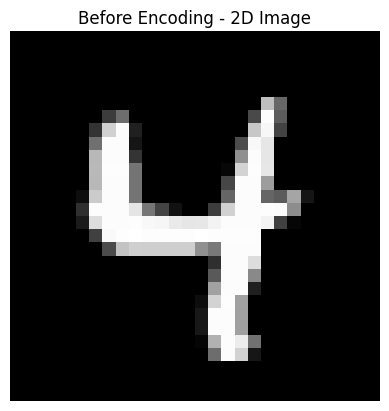

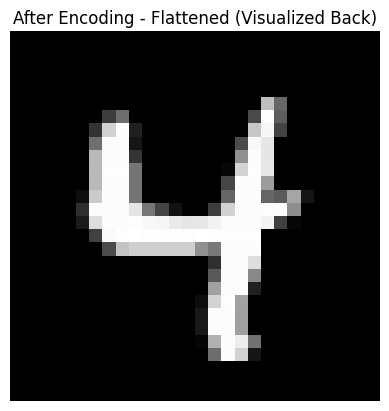

In [ ]:
# BEFORE
plt.imshow(img_after_tensor, cmap='gray')
plt.title("Before Encoding - 2D Image")
plt.axis("off")
plt.show()

# Flatten Encoding
img_flat = img_tensor.view(1, -1)

# Visualize flattened version reshaped back
img_flat_vis = img_flat.view(28, 28).detach().numpy()/225

# AFTER
plt.imshow(img_flat_vis, cmap='gray')
plt.title("After Encoding - Flattened (Visualized Back)")
plt.axis("off")
plt.show()


In [ ]:
# Encoder + Decoder using Sequential
model = torch.nn.Sequential(
    torch.nn.Linear(784, 128),
    torch.nn.ReLU(),
    torch.nn.Linear(128, 32),     # Encoded Representation

    torch.nn.Linear(32, 128),
    torch.nn.ReLU(),
    torch.nn.Linear(128, 784),
    torch.nn.Sigmoid()
)

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [ ]:
# Prepare full dataset flattened
train_images = train_dataset.data.float() / 255.0
train_images = train_images.view(-1, 784)

# Small quick training
for epoch in range(3):
    output = model(train_images)
    loss = loss_fn(output, train_images)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print("Epoch:", epoch, "Loss:", loss.item())


Epoch: 0 Loss: 0.231435164809227
Epoch: 1 Loss: 0.22957058250904083
Epoch: 2 Loss: 0.2275005578994751


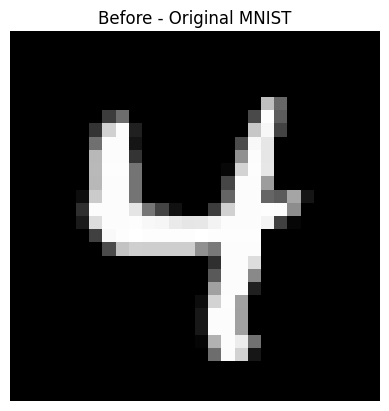

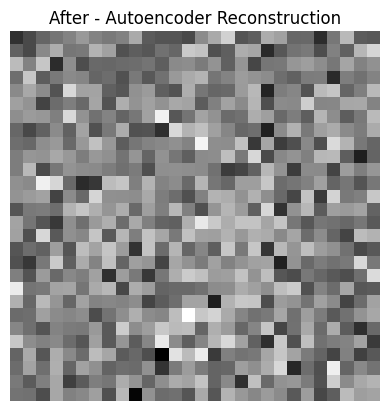

In [ ]:
# BEFORE (Original Image)
plt.imshow(img_original, cmap='gray')
plt.title("Before - Original MNIST")
plt.axis("off")
plt.show()

# Pass through Autoencoder
with torch.no_grad():
    reconstructed = model(img_flat)

img_recon = reconstructed.view(28, 28).numpy()

# AFTER (Encoded + Decoded)
plt.imshow(img_recon, cmap='gray')
plt.title("After - Autoencoder Reconstruction")
plt.axis("off")
plt.show()

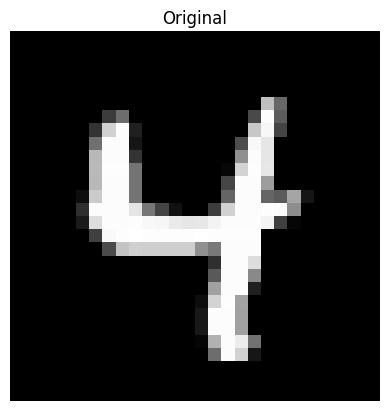

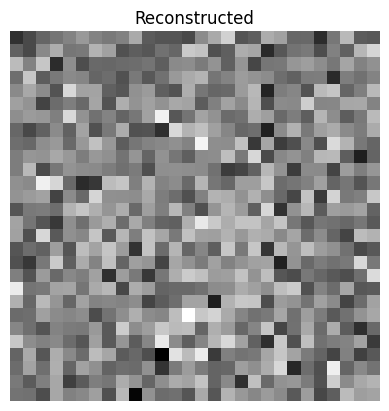

In [ ]:
# Original
plt.imshow(img_original, cmap='gray')
plt.title("Original")
plt.axis("off")
plt.show()

# Reconstructed
plt.imshow(img_recon, cmap='gray')
plt.title("Reconstructed")
plt.axis("off")
plt.show()

Epoch: 0 Loss: 0.2310798317193985
Epoch: 1 Loss: 0.2290498912334442
Epoch: 2 Loss: 0.22670550644397736
Epoch: 3 Loss: 0.2235763669013977
Epoch: 4 Loss: 0.21932527422904968


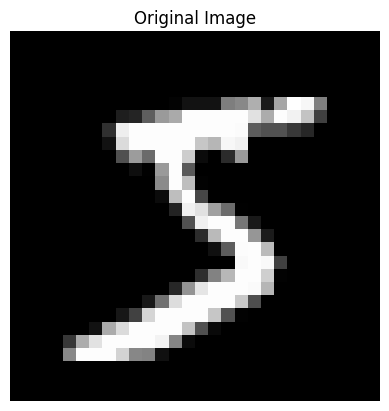

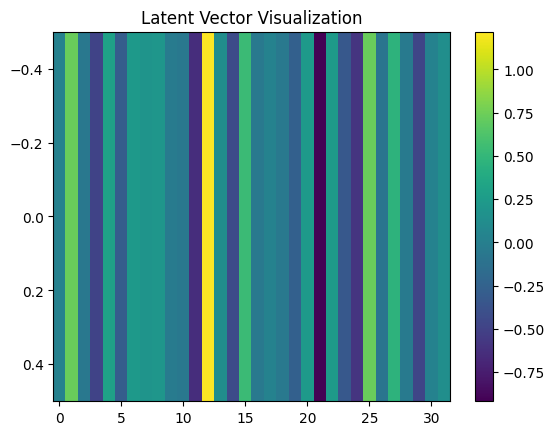

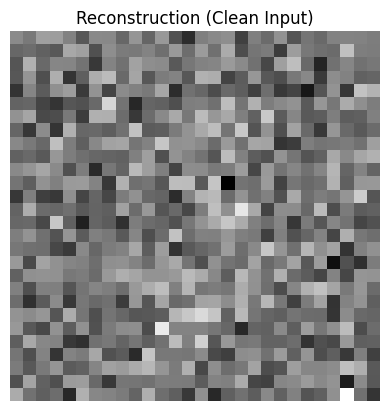

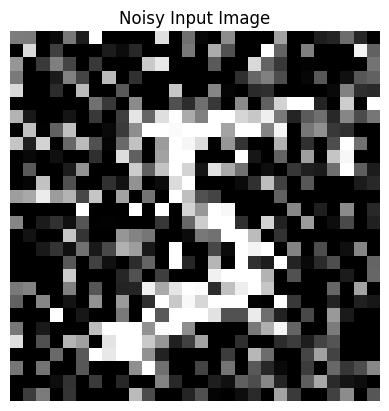

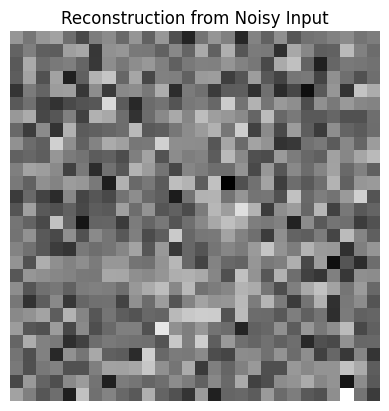

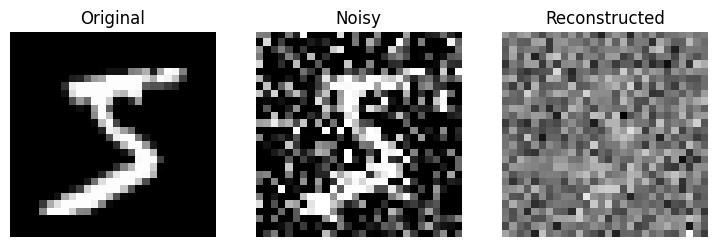

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Load MNIST
# -----------------------------
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True
)

# -----------------------------
# Prepare Training Data
# -----------------------------
train_images = train_dataset.data.float() / 255.0
train_images = train_images.view(-1, 784)

# -----------------------------
# Model (NO CLASS — Sequential)
# -----------------------------
encoder = torch.nn.Sequential(
    torch.nn.Linear(784, 128),
    torch.nn.ReLU(),
    torch.nn.Linear(128, 32)
)

decoder = torch.nn.Sequential(
    torch.nn.Linear(32, 128),
    torch.nn.ReLU(),
    torch.nn.Linear(128, 784),
    torch.nn.Sigmoid()
)

params = list(encoder.parameters()) + list(decoder.parameters())

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(params, lr=0.001)

# -----------------------------
# Training + Step-wise Loss Track
# -----------------------------
loss_list = []

for epoch in range(5):
    encoded = encoder(train_images)
    reconstructed = decoder(encoded)

    loss = loss_fn(reconstructed, train_images)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_list.append(loss.item())
    print("Epoch:", epoch, "Loss:", loss.item())


# -----------------------------
# Take One Sample Image
# -----------------------------
sample_img = train_images[0].view(1, 784)
sample_img_2d = sample_img.view(28, 28).detach().numpy()

plt.imshow(sample_img_2d, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

# -----------------------------
# Latent Vector Visualization
# -----------------------------
with torch.no_grad():
    latent_vec = encoder(sample_img)

latent_np = latent_vec.numpy().reshape(1, -1)

plt.figure()
plt.imshow(latent_np, aspect="auto")
plt.title("Latent Vector Visualization")
plt.colorbar()
plt.show()

# -----------------------------
# Reconstruction (Clean Input)
# -----------------------------
with torch.no_grad():
    recon_clean = decoder(latent_vec)

recon_clean_img = recon_clean.view(28, 28).numpy()

plt.imshow(recon_clean_img, cmap="gray")
plt.title("Reconstruction (Clean Input)")
plt.axis("off")
plt.show()

# -----------------------------
# Noise Robustness Test
# -----------------------------
noise = torch.randn_like(sample_img) * 0.5
noisy_img = sample_img + noise
noisy_img = torch.clamp(noisy_img, 0, 1)

noisy_img_2d = noisy_img.view(28, 28).numpy()

plt.imshow(noisy_img_2d, cmap="gray")
plt.title("Noisy Input Image")
plt.axis("off")
plt.show()

# -----------------------------
# Reconstruction from Noisy Input
# -----------------------------
with torch.no_grad():
    latent_noisy = encoder(noisy_img)
    recon_noisy = decoder(latent_noisy)

recon_noisy_img = recon_noisy.view(28, 28).numpy()

plt.imshow(recon_noisy_img, cmap="gray")
plt.title("Reconstruction from Noisy Input")
plt.axis("off")
plt.show()

# -----------------------------
# Final Comparison
# -----------------------------
plt.figure(figsize=(9,3))

plt.subplot(1,3,1)
plt.imshow(sample_img_2d, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(noisy_img_2d, cmap="gray")
plt.title("Noisy")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(recon_noisy_img, cmap="gray")
plt.title("Reconstructed")
plt.axis("off")

plt.show()


In [ ]:
# =====================================================
# IMPORT LIBRARIES
# =====================================================

import torch                         # Core PyTorch tensor + DL library
import torchvision                   # Dataset + vision utilities
import torchvision.transforms as transforms   # Image preprocessing
import matplotlib.pyplot as plt      # Plotting images and graphs


# =====================================================
# DEVICE SELECTION (GPU IF AVAILABLE)
# =====================================================

# If GPU available → use CUDA, else CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# =====================================================
# DATASET LOADING (MNIST)
# =====================================================

# Convert image → Tensor and scale pixel values 0–255 → 0–1
transform = transforms.ToTensor()

# Load MNIST dataset
train_dataset = torchvision.datasets.MNIST(
    root="./data",           # Folder to store dataset
    train=True,              # Load training data
    download=True,           # Download if not present
    transform=transform      # Apply preprocessing
)

# DataLoader → feeds data in batches during training
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=128,          # Number of images per batch
    shuffle=True             # Shuffle data every epoch
)


# =====================================================
# RESIDUAL AUTOENCODER (HIGH ACCURACY MODEL)
# =====================================================

# ---------- Residual Block 1 ----------
res_block1 = torch.nn.Sequential(
    torch.nn.Conv2d(1,16,3,padding=1),   # 1 channel → 16 feature maps
    torch.nn.ReLU(),                     # Non-linearity
    torch.nn.Conv2d(16,16,3,padding=1)   # Keep size same
).to(device)


# ---------- Residual Block 2 ----------
res_block2 = torch.nn.Sequential(
    torch.nn.Conv2d(16,32,3,stride=2,padding=1),  # Downsample 28 → 14
    torch.nn.ReLU(),
    torch.nn.Conv2d(32,32,3,padding=1)
).to(device)


# ---------- Projection Skip (CRITICAL FIX) ----------
# Needed because residual addition requires same shape
res_proj = torch.nn.Conv2d(16,32,1,stride=2).to(device)


# ---------- Latent Compression ----------
encoder_fc = torch.nn.Linear(32*14*14,64).to(device)   # Feature → Latent vector
decoder_fc = torch.nn.Linear(64,32*14*14).to(device)   # Latent → Feature


# ---------- Decoder ----------
decoder_conv = torch.nn.Sequential(
    torch.nn.ConvTranspose2d(32,16,4,stride=2,padding=1),  # Upsample 14 → 28
    torch.nn.ReLU(),
    torch.nn.Conv2d(16,1,3,padding=1),                    # Final image
    torch.nn.Sigmoid()                                    # Pixel values 0–1
).to(device)


# ---------- Optimizer + Loss ----------
params_res = (
    list(res_block1.parameters()) +
    list(res_block2.parameters()) +
    list(res_proj.parameters()) +
    list(encoder_fc.parameters()) +
    list(decoder_fc.parameters()) +
    list(decoder_conv.parameters())
)

opt_res = torch.optim.Adam(params_res, lr=0.001)
bce = torch.nn.BCELoss()   # Pixel reconstruction loss


# =====================================================
# RESIDUAL AE TRAINING
# =====================================================

loss_res_list = []

for epoch in range(5):

    running_loss = 0

    for imgs,_ in train_loader:

        imgs = imgs.to(device)

        # Residual Block 1
        # Add original image (copied across channels)
        x = torch.relu(res_block1(imgs) + imgs.repeat(1,16,1,1))

        # Residual Block 2 (with projection skip)
        x = torch.relu(res_block2(x) + res_proj(x))

        # Flatten feature map
        x_flat = x.view(x.size(0),-1)

        # Latent encoding
        latent = encoder_fc(x_flat)

        # Decode back
        x_dec = decoder_fc(latent)
        x_dec = x_dec.view(-1,32,14,14)
        recon = decoder_conv(x_dec)

        # Compute loss
        loss = bce(recon, imgs)

        # Backprop
        opt_res.zero_grad()
        loss.backward()
        opt_res.step()

        running_loss += loss.item()

    epoch_loss = running_loss/len(train_loader)
    loss_res_list.append(epoch_loss)

    print("Residual AE Epoch:", epoch, "Loss:", epoch_loss)


# =====================================================
# DENOISING AUTOENCODER (LEARNS NOISE REMOVAL)
# =====================================================

dae_encoder = torch.nn.Sequential(
    torch.nn.Conv2d(1,16,3,stride=2,padding=1),
    torch.nn.ReLU(),
    torch.nn.Conv2d(16,32,3,stride=2,padding=1),
    torch.nn.ReLU(),
    torch.nn.Flatten(),
    torch.nn.Linear(32*7*7,64)
).to(device)

dae_decoder = torch.nn.Sequential(
    torch.nn.Linear(64,32*7*7),
    torch.nn.ReLU(),
    torch.nn.Unflatten(1,(32,7,7)),
    torch.nn.ConvTranspose2d(32,16,4,stride=2,padding=1),
    torch.nn.ReLU(),
    torch.nn.ConvTranspose2d(16,1,4,stride=2,padding=1),
    torch.nn.Sigmoid()
).to(device)

params_dae = list(dae_encoder.parameters()) + list(dae_decoder.parameters())
opt_dae = torch.optim.Adam(params_dae, lr=0.001)

loss_dae_list = []

for epoch in range(5):

    running_loss = 0

    for imgs,_ in train_loader:

        imgs = imgs.to(device)

        # Add Gaussian noise
        noise = torch.randn_like(imgs)*0.4
        noisy = torch.clamp(imgs+noise,0,1)

        # Encode noisy image
        latent = dae_encoder(noisy)

        # Decode clean reconstruction
        recon = dae_decoder(latent)

        loss = bce(recon, imgs)

        opt_dae.zero_grad()
        loss.backward()
        opt_dae.step()

        running_loss += loss.item()

    epoch_loss = running_loss/len(train_loader)
    loss_dae_list.append(epoch_loss)

    print("DAE Epoch:", epoch, "Loss:", epoch_loss)


# =====================================================
# VARIATIONAL AUTOENCODER (PROBABILISTIC LATENT)
# =====================================================

vae_encoder = torch.nn.Sequential(
    torch.nn.Flatten(),
    torch.nn.Linear(784,256),
    torch.nn.ReLU(),
    torch.nn.Linear(256,128),
    torch.nn.ReLU()
).to(device)

vae_mu = torch.nn.Linear(128,32).to(device)
vae_logvar = torch.nn.Linear(128,32).to(device)

vae_decoder = torch.nn.Sequential(
    torch.nn.Linear(32,128),
    torch.nn.ReLU(),
    torch.nn.Linear(128,256),
    torch.nn.ReLU(),
    torch.nn.Linear(256,784),
    torch.nn.Sigmoid()
).to(device)

params_vae = (
    list(vae_encoder.parameters()) +
    list(vae_mu.parameters()) +
    list(vae_logvar.parameters()) +
    list(vae_decoder.parameters())
)

opt_vae = torch.optim.Adam(params_vae, lr=0.001)

loss_vae_list = []
beta = 0.5   # KL weight balance

for epoch in range(5):

    running_loss = 0

    for imgs,_ in train_loader:

        imgs = imgs.to(device)

        # Encode
        h = vae_encoder(imgs)

        # Distribution parameters
        mu = vae_mu(h)
        logvar = vae_logvar(h)

        # Reparameterization trick
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        z = mu + eps*std

        # Decode
        recon = vae_decoder(z).view(-1,1,28,28)

        # Loss = Reconstruction + KL divergence
        recon_loss = bce(recon, imgs)
        kl = -0.5*torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

        loss = recon_loss + beta*kl

        opt_vae.zero_grad()
        loss.backward()
        opt_vae.step()

        running_loss += loss.item()

    epoch_loss = running_loss/len(train_loader)
    loss_vae_list.append(epoch_loss)

    print("VAE Epoch:", epoch, "Loss:", epoch_loss)


# =====================================================
# LATENT INTERPOLATION DEMO
# =====================================================

img1 = train_dataset[1][0].unsqueeze(0).to(device)
img2 = train_dataset[2][0].unsqueeze(0).to(device)

with torch.no_grad():
    z1 = dae_encoder(img1)
    z2 = dae_encoder(img2)

alphas = torch.linspace(0,1,8)

plt.figure(figsize=(12,2))

for i,a in enumerate(alphas):
    z = z1*(1-a) + z2*a
    recon = dae_decoder(z)

    plt.subplot(1,8,i+1)
    plt.imshow(recon[0][0].cpu(), cmap="gray")
    plt.axis("off")

plt.suptitle("Latent Interpolation")
plt.show()


# =====================================================
# LOSS COMPARISON GRAPH
# =====================================================

plt.figure()
plt.plot(loss_res_list,label="Residual AE")
plt.plot(loss_dae_list,label="DAE")
plt.plot(loss_vae_list,label="VAE")
plt.legend()
plt.title("Loss Comparison")
plt.show()


# =====================================================
# NOISE ROBUSTNESS DEMO
# =====================================================

sample = train_dataset[0][0].unsqueeze(0).to(device)

noise = torch.randn_like(sample)*0.5
noisy = torch.clamp(sample+noise,0,1)

with torch.no_grad():
    recon_noisy = dae_decoder(dae_encoder(noisy))

plt.figure(figsize=(9,3))

plt.subplot(1,3,1)
plt.imshow(sample[0][0].cpu(), cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(noisy[0][0].cpu(), cmap="gray")
plt.title("Noisy")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(recon_noisy[0][0].cpu(), cmap="gray")
plt.title("Reconstructed")
plt.axis("off")

plt.show()


Residual AE Epoch: 0 Loss: 0.12667828175558973
Residual AE Epoch: 1 Loss: 0.07118877990921932
Residual AE Epoch: 2 Loss: 0.0683549991421608
Residual AE Epoch: 3 Loss: 0.06733050229135099
Residual AE Epoch: 4 Loss: 0.0666677390239132
DAE Epoch: 0 Loss: 0.20448451887951222


100%|██████████| 9.91M/9.91M [00:00<00:00, 19.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 679kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.76MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.37MB/s]


Epoch: 0 D Loss: 0.030427254736423492 G Loss: 6.274796962738037
Epoch: 1 D Loss: 0.0026752413250505924 G Loss: 8.019526481628418
Epoch: 2 D Loss: 0.0008596158586442471 G Loss: 8.31796932220459
Epoch: 3 D Loss: 0.0002653297269716859 G Loss: 8.843231201171875
Epoch: 4 D Loss: 0.00021066205226816237 G Loss: 8.391622543334961


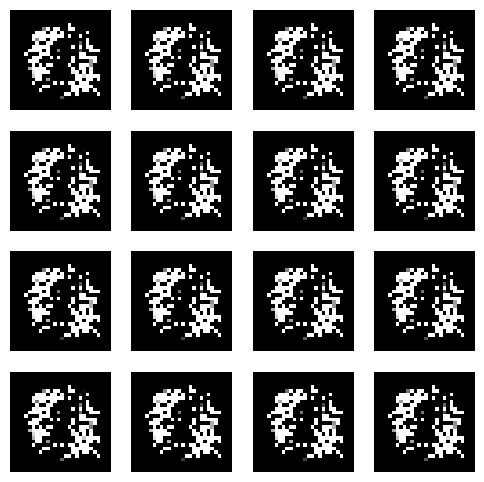

In [1]:
# ==============================
# IMPORTS
# ==============================
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# ==============================
# DEVICE
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==============================
# DATASET (MNIST)
# ==============================
transform = transforms.ToTensor()

dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)

# ==============================
# GENERATOR (Noise → Image)
# ==============================
G = torch.nn.Sequential(
    torch.nn.Linear(1000, 2560),
    torch.nn.ReLU(),
     torch.nn.Linear(10000, 256000),
    torch.nn.ReLU(),
    torch.nn.Linear(256, 512),
    torch.nn.ReLU(),
    torch.nn.Linear(512, 784),
    torch.nn.Sigmoid()
).to(device)

# ==============================
# DISCRIMINATOR (Image → Real/Fake)
# ==============================
D = torch.nn.Sequential(
    torch.nn.Linear(784, 512),
    torch.nn.ReLU(),
    torch.nn.Linear(512, 256),
    torch.nn.ReLU(),
    torch.nn.Linear(256, 1),
    torch.nn.Sigmoid()
).to(device)

# ==============================
# OPTIMIZERS + LOSS
# ==============================
opt_G = torch.optim.Adam(G.parameters(), lr=0.0002)
opt_D = torch.optim.Adam(D.parameters(), lr=0.0002)

loss_fn = torch.nn.BCELoss()

# ==============================
# TRAINING
# ==============================
epochs = 5

for epoch in range(epochs):

    for real_imgs,_ in loader:

        real_imgs = real_imgs.view(-1, 784).to(device)

        # ======================
        # TRAIN DISCRIMINATOR
        # ======================

        noise = torch.randn(real_imgs.size(0), 100).to(device)
        fake_imgs = G(noise)

        real_labels = torch.ones(real_imgs.size(0),1).to(device)
        fake_labels = torch.zeros(real_imgs.size(0),1).to(device)

        real_loss = loss_fn(D(real_imgs), real_labels)
        fake_loss = loss_fn(D(fake_imgs.detach()), fake_labels)

        d_loss = real_loss + fake_loss

        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

        # ======================
        # TRAIN GENERATOR
        # ======================

        noise = torch.randn(real_imgs.size(0), 100).to(device)
        fake_imgs = G(noise)

        g_loss = loss_fn(D(fake_imgs), real_labels)

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

    print("Epoch:", epoch, "D Loss:", d_loss.item(), "G Loss:", g_loss.item())

# ==============================
# GENERATE SAMPLE IMAGES
# ==============================
noise = torch.randn(16, 100).to(device)

with torch.no_grad():
    gen_imgs = G(noise).view(-1,28,28).cpu()

plt.figure(figsize=(6,6))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(gen_imgs[i], cmap="gray")
    plt.axis("off")
plt.show()
